# Clustering

#### Sebastian Miramontes Soto

### Data Preparation

In [31]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.metrics import (adjusted_rand_score,normalized_mutual_info_score)

In [32]:
df = pd.read_csv("../DATA CLEANING AND EDA/cleaned_dataset.csv")

In [33]:
names = df["player_name"].copy()

categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]).columns.tolist()

categorical_cols = [
    col for col in categorical_cols
    if col != "player_name"]


df = pd.get_dummies(df, columns=categorical_cols, dtype=int)

X = df.drop(columns=["player_name"]).copy()

In [34]:
important = [
    "offsides_per90",
    "shots_total_per90",
    "shots_on_per90",
    "goals_total_per90",
    "assists_per90",
    "goals_plus_assists_per90",
    "non_penalty_goals_per90",
    "passes_total_per90",
    "passes_key_per90",
    "tackles_total_per90",
    "blocks_per90",
    "interceptions_per90",
    "tackles_plus_interceptions_per90",
    "duels_total_per90",
    "duels_won_per90",
    "dribbles_attempts_per90",
    "dribbles_success_per90",
    "dribbles_past_per90",
    "fouls_drawn_per90",
    "fouls_committed_per90",
    "yellow_cards_per90",
    "yellowred_cards_per90",
    "red_cards_per90",
    "passes_accuracy_pct",
    "shots_on_target_pct",
    "duels_won_pct",
    "dribbles_success_pct",
    "position_D", "position_F", "position_M"]

binary_cols = [
    col for col in X.columns
    if any(col.startswith(f"{cat}_") for cat in categorical_cols)]

numeric_cols = [
    col for col in X.columns
    if col not in binary_cols]

X_scaled = X.astype(float).copy()

scaler = RobustScaler()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

WEIGHT1 = 1.0
WEIGHT2 = 0.2

for col in X_scaled.columns:
    X_scaled[col] *= WEIGHT1 if col in important else WEIGHT2

X = X_scaled.copy()

In [35]:
X.head()

,appearances,starts,minutes,goals_total,assists,penalty_won,penalty_committed,penalty_scored,penalty_missed,yellow_cards,...,nationality_group_CONCACAF,nationality_group_CONMEBOL,nationality_group_OFC,nationality_group_UEFA,height_155-162,height_163-170,height_171-178,height_179-186,height_187-194,height_195-202
0,-0.261538,-0.1250,-0.130374,0.000000,-0.066667,0.0,0.0,0.0,0.0,-0.05,...,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0
1,0.092308,0.1250,0.119571,-0.066667,0.066667,0.0,0.0,0.0,0.0,0.40,...,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0
2,-0.092308,-0.1250,-0.138365,-0.066667,-0.066667,0.0,0.0,0.0,0.0,-0.10,...,0.0,0.0,0.0,0.2,0.0,0.0,0.2,0.0,0.0,0.0
3,-0.107692,0.0250,-0.003552,0.000000,-0.066667,0.0,0.0,0.0,0.0,-0.10,...,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0
4,-0.230769,-0.1625,-0.168701,-0.066667,-0.066667,0.0,0.0,0.0,0.0,-0.15,...,0.0,0.0,0.0,0.2,0.0,0.0,0.2,0.0,0.0,0.0


## K-means

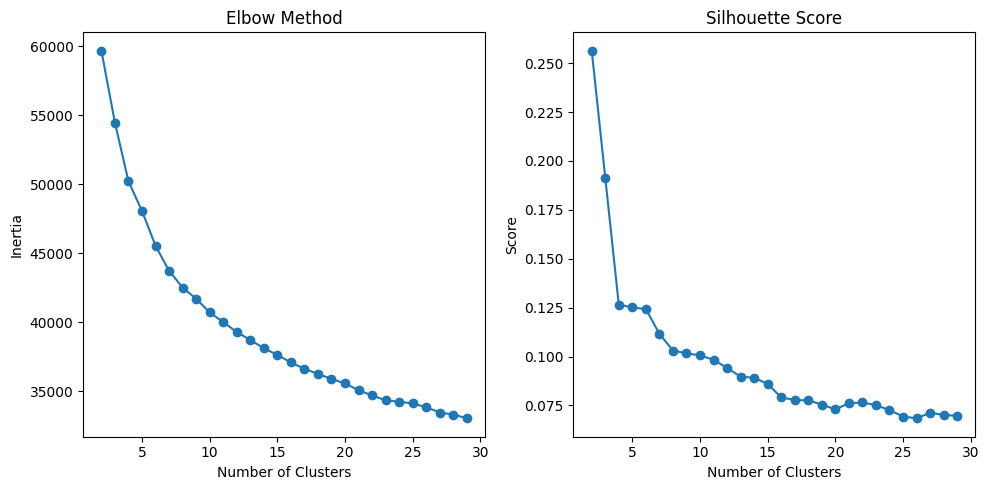

In [36]:
K = range(2, 30)

inertia = []
silhouette = []

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, labels))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(K, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K, silhouette, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [37]:
k = 8

kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")

kmeans_labels = kmeans.fit_predict(X)

## Agglomerative

In [38]:
agg = AgglomerativeClustering( n_clusters=k, linkage="ward")

agg_labels = agg.fit_predict(X)

## Comparison

### KMeans

In [39]:
print(f"Number of clusters: {k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X, kmeans_labels):.3f}")
df["kmeans_cluster"] = kmeans_labels
print(df["kmeans_cluster"].value_counts().sort_index())


Number of clusters: 8
Inertia: 42511.70
Silhouette Score: 0.103
kmeans_cluster
0    927
1    767
2    430
3    530
4    522
5    298
6    555
7    814
Name: count, dtype: int64


In [40]:
position_cols = [c for c in df.columns if c.startswith("position_")]
age_cols = [c for c in df.columns if c.startswith("age_")]
height_cols = [c for c in df.columns if c.startswith("height_")]

for c in sorted(df["kmeans_cluster"].unique()):
    x = df[df["kmeans_cluster"] == c]
    print(
        f"Cluster {c}: "
        f"{x[position_cols].mean().idxmax()} {100*x[position_cols].mean().max():.1f}% | "
        f"{x[age_cols].mean().idxmax()} {100*x[age_cols].mean().max():.1f}% | "
        f"{x[height_cols].mean().idxmax()} {100*x[height_cols].mean().max():.1f}%")

Cluster 0: position_M 62.9% | age_25-27 30.2% | height_179-186 41.3%
Cluster 1: position_D 94.8% | age_28-31 28.2% | height_187-194 49.2%
Cluster 2: position_F 92.6% | age_21-24 27.2% | height_179-186 43.0%
Cluster 3: position_D 88.5% | age_28-31 27.4% | height_179-186 48.1%
Cluster 4: position_F 53.3% | age_21-24 40.4% | height_171-178 47.5%
Cluster 5: position_F 89.9% | age_25-27 29.5% | height_179-186 46.6%
Cluster 6: position_M 58.4% | age_21-24 29.7% | height_171-178 50.5%
Cluster 7: position_M 62.2% | age_21-24 33.5% | height_179-186 42.1%


### Agglomerative

In [41]:
print(f"Number of clusters: {k}")
print(f"Silhouette Score: {silhouette_score(X, agg_labels):.3f}")
df["agg_cluster"] = agg_labels
print(df["agg_cluster"].value_counts().sort_index())


Number of clusters: 8
Silhouette Score: 0.079
agg_cluster
0    941
1    564
2    412
3    839
4    826
5    992
6     99
7    170
Name: count, dtype: int64


In [42]:
for c in sorted(df["agg_cluster"].unique()):
    x = df[df["agg_cluster"] == c]
    print(
        f"Cluster {c}: "
        f"{x[position_cols].mean().idxmax()} {100*x[position_cols].mean().max():.1f}% | "
        f"{x[age_cols].mean().idxmax()} {100*x[age_cols].mean().max():.1f}% | "
        f"{x[height_cols].mean().idxmax()} {100*x[height_cols].mean().max():.1f}%")

Cluster 0: position_M 57.5% | age_21-24 33.3% | height_171-178 46.8%
Cluster 1: position_F 95.6% | age_28-31 25.9% | height_179-186 45.0%
Cluster 2: position_M 48.3% | age_21-24 38.6% | height_171-178 47.1%
Cluster 3: position_D 98.9% | age_28-31 27.9% | height_187-194 49.7%
Cluster 4: position_M 69.1% | age_21-24 32.9% | height_179-186 42.9%
Cluster 5: position_D 55.3% | age_25-27 27.3% | height_179-186 44.7%
Cluster 6: position_F 97.0% | age_25-27 34.3% | height_179-186 44.4%
Cluster 7: position_D 88.8% | age_28-31 29.4% | height_187-194 46.5%


In [43]:
cluster_percentages = pd.crosstab(df["kmeans_cluster"], df["agg_cluster"], normalize="index") * 100

cluster_percentages.index = [f"K{i}" for i in cluster_percentages.index]

cluster_percentages.columns = [f"A{i}" for i in cluster_percentages.columns]

display(cluster_percentages.round(1))

,A0,A1,A2,A3,A4,A5,A6,A7
K0,19.1,0.0,0.5,1.1,17.2,62.0,0.0,0.1
K1,0.0,0.0,0.0,89.6,3.5,6.9,0.0,0.0
K2,13.7,83.7,2.6,0.0,0.0,0.0,0.0,0.0
K3,0.0,0.0,0.0,23.0,4.0,41.3,0.0,31.7
K4,33.0,1.7,63.6,0.0,1.7,0.0,0.0,0.0
K5,18.1,45.6,3.0,0.0,0.0,0.0,33.2,0.0
K6,82.2,10.6,4.1,0.0,0.7,2.3,0.0,0.0
K7,2.8,0.0,3.9,2.5,74.4,16.2,0.0,0.1


In [44]:
ari = adjusted_rand_score(df["kmeans_cluster"], df["agg_cluster"])

nmi = normalized_mutual_info_score(df["kmeans_cluster"], df["agg_cluster"])

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

Adjusted Rand Index: 0.446
Normalized Mutual Information: 0.561


In [45]:
df.to_csv("final_dataset.csv", index=False)